In [5]:
!pip install evaluate --quiet
!pip install datasets --quiet
!pip install scikit-learn --quiet
!pip install matplotlib --quiet
!pip install protobuf==3.20.3 --quiet

import torch
import numpy as np
import evaluate
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer, 
    DataCollatorWithPadding,
    pipeline,
    set_seed
)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

SEED = 42
set_seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

try:
    hf_token = UserSecretsClient().get_secret("huggingface")
    login(token=hf_token)
except Exception as e:
    print(f"Login warning: {e}")

In [6]:
MODEL_CKPT = "distilbert-base-uncased"
DATASET_NAME = "ag_news"
NUM_LABELS = 4
BATCH_SIZE = 32
LEARNING_RATE = 2e-5
NUM_EPOCHS = 3
WEIGHT_DECAY = 0.0
OUTPUT_DIR = "distilbert-ag-news-classifier"
HF_REPO_NAME = "distilbert-ag-news-classifier"

id2label = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
label2id = {"World": 0, "Sports": 1, "Business": 2, "Sci/Tech": 3}

In [7]:
dataset = load_dataset(DATASET_NAME)
tokenizer = AutoTokenizer.from_pretrained(MODEL_CKPT)

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True)

tokenized_dataset = dataset.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

...

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [8]:
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    acc_result = accuracy.compute(predictions=predictions, references=labels)
    f1_result = f1.compute(predictions=predictions, references=labels, average="weighted")
    
    return {
        "accuracy": acc_result["accuracy"],
        "f1": f1_result["f1"]
    }

In [9]:
NUM_LAYERS_TO_FREEZE = 0 

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CKPT, 
    num_labels=NUM_LABELS,
    id2label=id2label, 
    label2id=label2id
)

if NUM_LAYERS_TO_FREEZE > 0:
    print(f"Freezing first {NUM_LAYERS_TO_FREEZE} transformer layers")
    for i in range(NUM_LAYERS_TO_FREEZE):
        try:
            layer = model.distilbert.transformer.layer[i]
            for param in layer.parameters():
                param.requires_grad = False
            print(f"- Layer {i} frozen")
        except IndexError:
            print(f"Warning: Layer {i} index out of bounds")
    print(f"Successfully frozen {NUM_LAYERS_TO_FREEZE} layers")
else:
    print("Full Fine-Tuning mode enabled")

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable Parameters: {trainable_params:,}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Full Fine-Tuning mode enabled
Trainable Parameters: 66,956,548


In [10]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=WEIGHT_DECAY,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=500,
    load_best_model_at_end=True,
    report_to="none",
    push_to_hub=False,
    hub_model_id=HF_REPO_NAME
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.185300,0.174853,0.939737,0.939802
2,0.135000,0.168363,0.947368,0.947444
3,0.086200,0.186563,0.946579,0.946612


TrainOutput(global_step=11250, training_loss=0.15026600121392145, metrics={'train_runtime': 2198.4398, 'train_samples_per_second': 163.752, 'train_steps_per_second': 5.117, 'total_flos': 1.0729794901335552e+16, 'train_loss': 0.15026600121392145, 'epoch': 3.0})

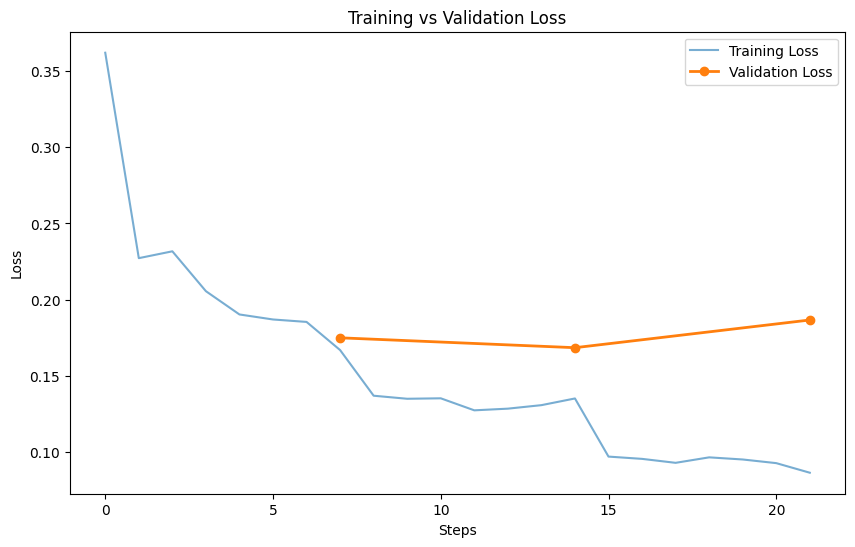

In [11]:
history = trainer.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]

plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss', alpha=0.6)
if eval_loss:
    steps_per_epoch = len(train_loss) // len(eval_loss)
    eval_steps = list(range(steps_per_epoch, len(train_loss) + 1, steps_per_epoch))
    plt.plot(eval_steps, eval_loss, label='Validation Loss', marker='o', linewidth=2)

plt.title('Training vs Validation Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.show()

Final Test Metrics: {'test_loss': 0.16836287081241608, 'test_accuracy': 0.9473684210526315, 'test_f1': 0.9474438104912288, 'test_runtime': 13.0342, 'test_samples_per_second': 583.079, 'test_steps_per_second': 18.26}


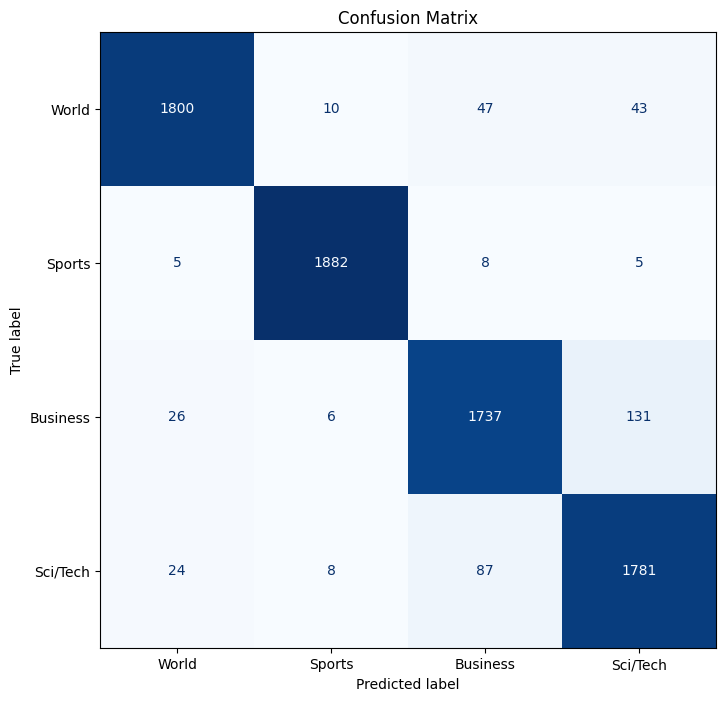

In [12]:
test_results = trainer.predict(tokenized_dataset["test"])
print("Final Test Metrics:", test_results.metrics)

y_true = test_results.label_ids
y_pred = np.argmax(test_results.predictions, axis=1)
labels_list = [id2label[i] for i in range(NUM_LABELS)]

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_list)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title("Confusion Matrix")
plt.show()

In [13]:
device = 0 if torch.cuda.is_available() else -1
test_pipeline = pipeline("text-classification", model=trainer.model, tokenizer=tokenizer, device=device)

sample_text = "Stock market hits all-time high amid tech boom."
result = test_pipeline(sample_text)

print(f"Input: {sample_text}")
print(f"Prediction: {result}")

Device set to use cuda:0


Input: Stock market hits all-time high amid tech boom.
Prediction: [{'label': 'Business', 'score': 0.9896137118339539}]


In [ ]:
trainer.push_to_hub()
print(f"Model pushed to: {HF_REPO_NAME}")